# Weak-lensing galaxy shape catalogue validation

## Local metacalibration

Contents.
- Metacalibration (local)

> **_NOTE:_** Before running this notebook, set kernel to `main_set.ipynb'

In [68]:
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
from lenspack.geometry.projections.gnom import radec2xy

from sp_validation.io import *
from sp_validation.galaxy import *

In [69]:
plot_dir_local = f'{plot_dir}/local_cal_ngmix'

### Spatial binning

In [94]:
# Projection all objects from spherical to Cartesian coordinates
x, y =  radec2xy(np.mean(ra_ngmix), np.mean(dec_ngmix), ra_ngmix, dec_ngmix)

#### Compute and enlarge field size

In [71]:
# Define mix, max and size
min_x = np.min(x)
max_x = np.max(x)
min_y = np.min(y)
max_y = np.max(y)

size_x = max_x - min_x
size_y = max_y - min_y
size_x_deg = np.rad2deg(size_x)
size_y_deg = np.rad2deg(size_y)

print(f'Field size in projected coordinates is (x, y) = ({size_x_deg:.2f}, {size_y_deg:.2f}) deg')

Field size in projected coordinates is (x, y) = (8.61, 7.19) deg


In [72]:
# Calibration pixel sizes for local calibration, in degree
cal_pix_size_deg = [1, 2, 4]

n_cal = len(cal_pix_size_deg)

# The following arrays need to have a length equal or larger n_cal
colors = ['blue', 'red', 'green']
linestyles = ['-', '-', '-']

In [73]:
# Compute larger field size, divisible by largest subfield size
factor = max(cal_pix_size_deg)

size_x_deg_new = np.ceil(size_x_deg / factor) * factor
size_y_deg_new = np.ceil(size_y_deg / factor) * factor

print(f'Enlarged field size in projected coordinates is (x, y) = ({size_x_deg_new:.1f}, {size_y_deg_new:.1f}) deg')

Enlarged field size in projected coordinates is (x, y) = (12.0, 8.0) deg


In [74]:
# Modify max coordinates to account for enlarged field
max_x_new = max_x + np.deg2rad(size_x_deg_new - size_x_deg)
max_y_new = max_y + np.deg2rad(size_y_deg_new - size_y_deg)
size_x_new = max_x_new - min_x
size_y_new = max_y_new - min_y

# Check that new size is ok
print('Check new field size:', np.rad2deg(size_x_new), np.rad2deg(size_y_new))

Check new field size: 12.000000000000002 8.0


#### Local calibration

In [95]:
def local_calib(dd, x, y, min_x, max_x, min_y, max_y, npix_x, npix_y, R_shear_moy, R_selec_moy, dm, sigm, stats_file=None, verbose=False):
    """Local Calib
    
    Local calibration.
    """
    
    # Mean total calibration matrix
    R_tot_moy = R_shear_moy + R_selec_moy
    
    g1_final = np.array([])
    g2_final = np.array([])
    g1_final_dm = np.array([])
    g2_final_dm = np.array([])
    R_selec = np.zeros((2, 2, npix_y, npix_x))
    R_shear = np.zeros((2, 2, npix_y, npix_x))
    ra_ngmix2 = np.array([])
    dec_ngmix2 = np.array([])
    R_selec_std = np.zeros((2, 2, npix_y, npix_x))
    R_shear_std = np.zeros((2, 2, npix_y, npix_x))
    c1_ngmix_cut = np.zeros((npix_y, npix_x))
    c2_ngmix_cut = np.zeros((npix_y, npix_x))
    err_c1_ngmix_cut = np.zeros((npix_y, npix_x))
    err_c2_ngmix_cut = np.zeros((npix_y, npix_x))
    
    ngal = bin2d(x, y, npix=(npix_x, npix_y), extent=(min_x, max_x, min_y, max_y))

    # Cut the catalogue into calibration pixels -> dd_cut
    for i in range(npix_x):
        for j in range(npix_y):
            if i == npix_x and j != npix_y:
                dd_cut = dd[np.where((x >= min_x + (i*size_x_new/npix_x)) & (x <= max_x) \
                                     & (y >= min_y + (j*size_y_new/npix_y)) & (y < min_y + ((j+1)*size_y_new/npix_y)))]
            elif j== npix_x and i != npix_y:
                dd_cut = dd[np.where((x >= min_x + (i*size_x_new/npix_x)) & (x < min_x + ((i+1)*size_x_new/npix_x)) \
                                     & (y >= min_y + (j*size_y_new/npix_y)) & (y <= max_y))] 
            elif j == npix_x and i == npix_y:
                dd_cut = dd[np.where((x >= min_x + (i*size_x_new/npix_x)) & (x <= max_x) \
                                     & (y >= min_y + (j*size_y_new/npix_y)) & (y <= max_y ))]
            else:
                dd_cut = dd[np.where((x >= min_x + (i*size_x_new/npix_x)) & (x < min_x + ((i+1)*size_x_new/npix_x)) \
                                     & (y >= min_y + (j*size_y_new/npix_y)) & (y < min_y + ((j+1)*size_y_new/npix_y)))]
        
            # Mask of dd_cut
            cut_common = classification_galaxy_base(dd_cut)
            m_gal_ngmix_cut = classification_galaxy_ngmix(dd_cut, cut_common, stats_file=stats_file, verbose=verbose)

            # Apply metacal to dd_cut. No verbose output
            gal_metacal_ngmix_cut = metacal(dd_cut, m_gal_ngmix_cut, verbose=False)
        
            # Save ra & dec to keep the order        
            ra_ngmix_temp = dd_cut['XWIN_WORLD'][m_gal_ngmix_cut][gal_metacal_ngmix_cut.mask_dict['ns']]
            ra_ngmix2 = np.concatenate((ra_ngmix2, ra_ngmix_temp))
            dec_ngmix_temp = dd_cut['YWIN_WORLD'][m_gal_ngmix_cut][gal_metacal_ngmix_cut.mask_dict['ns']]
            dec_ngmix2 = np.concatenate((dec_ngmix2, dec_ngmix_temp))
            
            w_ngmix_cut = gal_metacal_ngmix_cut.ns['w'][gal_metacal_ngmix_cut.mask_dict['ns']]
        
            g_ngmix_cut = np.array([gal_metacal_ngmix_cut.ns['g1'][gal_metacal_ngmix_cut.mask_dict['ns']], gal_metacal_ngmix_cut.ns['g2'][gal_metacal_ngmix_cut.mask_dict['ns']]])
        
            # If numver of galaxy is ok, metacal local
            if ngal[j,i] > np.mean(ngal) / 2:
                g_corr_ngmix_cut = np.linalg.inv(gal_metacal_ngmix_cut.R).dot(g_ngmix_cut)
                
                # Add of delta m 
                R_dm = gal_metacal_ngmix_cut.R + np.ones((2,2)) * (dm + np.random.normal(0, sigm))
                g_corr_ngmix_cut_dm = np.linalg.inv(R_dm).dot(g_ngmix_cut)
                
                # Additive bias
                c1_ngmix_cut[j,i], err_c1_ngmix_cut[j,i] = jackknif_weighted_average2(g_corr_ngmix_cut[0], w_ngmix_cut, remove_size=0.05, n_realization=500)
                c2_ngmix_cut[j,i], err_c2_ngmix_cut[j,i] = jackknif_weighted_average2(g_corr_ngmix_cut[1], w_ngmix_cut, remove_size=0.05, n_realization=500)
                
                # Save R matrix and std
                R_selec[:,:,j,i] = gal_metacal_ngmix_cut.R_selection
                R_shear[:,:,j,i] = np.mean(gal_metacal_ngmix_cut.R_shear,2)
                                
            # If low number of galaxy, we use value of globaal metacal
            else:
                g_corr_ngmix_cut = np.linalg.inv(R_tot_moy).dot(g_ngmix_cut)
                R_dm = R_tot_moy + np.ones((2,2)) * (dm + np.random.normal(0, sigm))
                g_corr_ngmix_cut_dm = np.linalg.inv(R_dm).dot(g_ngmix_cut)
                
                c1_ngmix_cut[j,i] = 0
                err_c1_ngmix_cut[j,i] = 0
                c2_ngmix_cut[j,i] = 0
                err_c2_ngmix_cut[j,i] = 0
            
                R_selec[:,:,j,i] = R_selec_moy
                R_shear[:,:,j,i] = R_shear_moy
                             
            g1_final = np.concatenate((g1_final, g_corr_ngmix_cut[0]))  
            g2_final = np.concatenate((g2_final, g_corr_ngmix_cut[1]))
            g1_final_dm = np.concatenate((g1_final_dm, g_corr_ngmix_cut_dm[0]))  
            g2_final_dm = np.concatenate((g2_final_dm, g_corr_ngmix_cut_dm[1]))
            
            g_final = np.array([g1_final, g2_final])
            g_final_dm = np.array([g1_final_dm, g2_final_dm])
            c_ngmix_cut = np.array([c1_ngmix_cut, c2_ngmix_cut])
            err_c_ngmix_cut = np.array([err_c1_ngmix_cut, err_c2_ngmix_cut])
    
    return g_final, g_final_dm, R_shear, R_selec, ra_ngmix2, dec_ngmix2, c_ngmix_cut, err_c_ngmix_cut

In [96]:
g_corr_ngmix_local = {}
g_corr_ngmix_local_dm = {}
R_shear_local = {}
R_selec_local = {}
ra_ngmix_local = {}
dec_ngmix_local = {}
c_ngmix_local = {}
c_err_ngmix_local = {}

# Additional mean and std of multiplicative bias
m = 0
dm = 0

# Loop over different calibration pixel sizes
for cal_pix in cal_pix_size_deg:
    npix_x = int(size_x_deg_new / cal_pix)
    npix_y = int(size_y_deg_new / cal_pix)
    if verbose:
        print(f'Calibration pixel size = {cal_pix} deg, number of pixels = {npix_x} x {npix_y}')
    
    # Call local_calibration with verbose=False to avoid too much std output
    (
        g_corr_ngmix_local[cal_pix],
        g_corr_ngmix_local_dm[cal_pix],
        R_shear_local[cal_pix],
        R_selec_local[cal_pix],
        ra_ngmix_local[cal_pix],
        dec_ngmix_local[cal_pix],
        c_ngmix_local[cal_pix],
        c_err_ngmix_local[cal_pix]
    ) = local_calib(dd, x, y, min_x, max_x_new, min_y, max_y_new, npix_x, npix_y,
                    R_shear_ngmix, gal_metacal_ngmix.R_selection, m, dm, stats_file=None, verbose=False)

Calibration pixel size = 1 deg, number of pixels = 12 x 8


/Users/mkilbing/anaconda3/envs/shapepipe/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3372: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/mkilbing/anaconda3/envs/shapepipe/lib/python3.8/site-packages/numpy/core/_methods.py:170: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/Users/mkilbing/anaconda3/envs/shapepipe/lib/python3.8/site-packages/numpy/core/_methods.py:162: RuntimeWarning: invalid value encountered in true_divide
  ret = um.true_divide(


Calibration pixel size = 2 deg, number of pixels = 6 x 4
Calibration pixel size = 4 deg, number of pixels = 3 x 2


### Plots

In [78]:
def sub_plot(nx, ny, i, im, title):
    """Sub Plot
    
    Create sub plot.
    
    Parameters
    ----------
    nx, ny : int
        number of rows and columns
    i : int
        subplot number
    im : 2D array of float
        image
    title : string
        plot title text
    """

    plt.subplot(nx, ny, i)
        
    ax = plt.gca()
    im = ax.imshow(im)
        
    plt.title(title ,fontsize=fontsize)
        
    divider = make_axes_locatable(ax)
        
    plt.xticks(fontsize=fontsize)

    plt.yticks(fontsize=fontsize)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    plt.colorbar(im, cax=cax)
    plt.yticks(fontsize=fontsize)

#### Additive bias

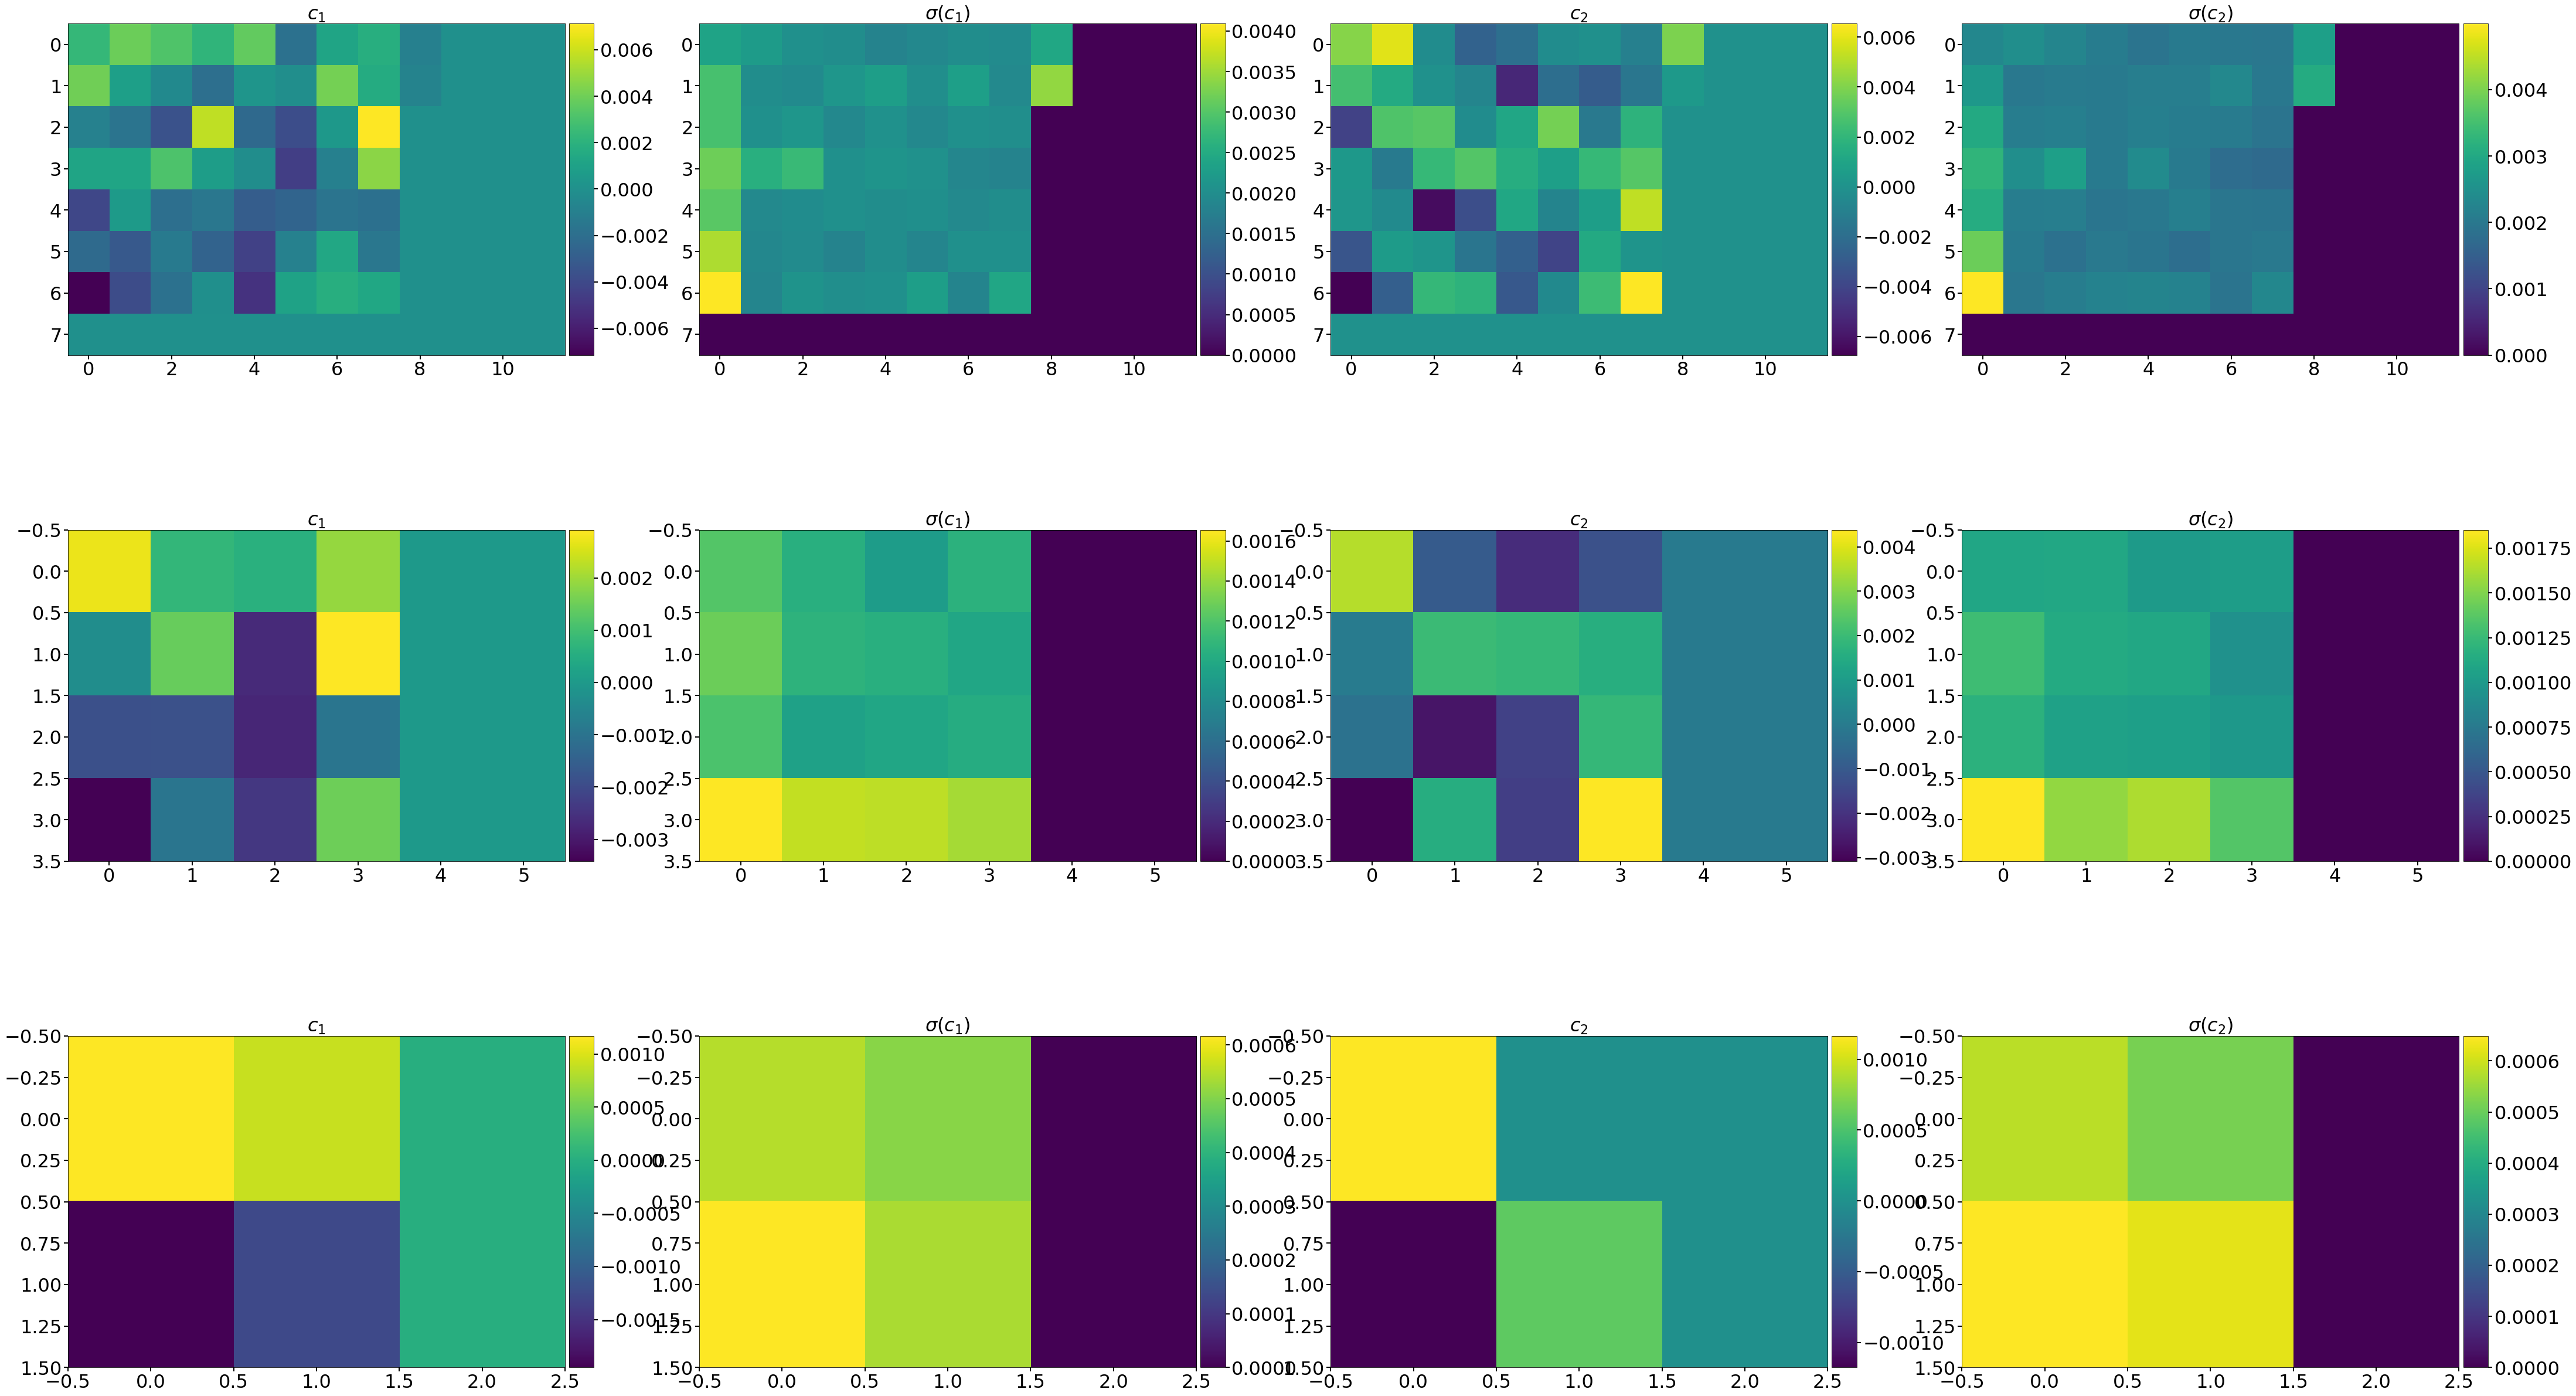

In [80]:
# Spatial variations

fontsize = 32
plt.figure(figsize=(74, 45))

for i, cal_pix in enumerate(cal_pix_size_deg):

    for comp in (0, 1):
        subf = 4*i + 2*comp + 1
        
        sub_plot(n_cal, 4, subf, c_ngmix_local[cal_pix][comp], rf'$c_{comp+1}$')
        sub_plot(n_cal, 4, subf+1, c_err_ngmix_local[cal_pix][comp], rf'$\sigma(c_{comp+1})$')
        
plt.savefig(f'{plot_dir_local}/c_spatial.pdf', bbox_inches = 'tight',pad_inches = 0)

### Response matrices

In [81]:
# Uncertainty via jackknife

def compute_R_std(npix_x, npix_y, factor, R):
    """Compute R Std
    """
    
    R_std = np.zeros((2, 2, npix_y, npix_x))

    for i in range(npix_y):
        for j in range(npix_x):
            
            for c1 in (0, 1):
                for c2 in (0, 1):
                    R_ref = R[c1,c2,factor*i:factor*(i+1),factor*j:factor*(j+1)]
                    if np.sum(R_ref) != 0:
                        R_ref_1d = np.ravel(R_ref)
                        R_std[c1, c2, i, j] = jackknif_weighted_average(R_ref_1d, np.ones_like(R_ref_1d))[1]
                    else:
                        R_std[c1,c2,i,j] = np.nan
                
    return R_std

In [82]:
R_shear_std_local = {}
R_selec_std_local = {}

# Reference = minimum pixel size
cal_pix_ref = min(cal_pix_size_deg)

for cal_pix in cal_pix_size_deg:
    
    if cal_pix == cal_pix_ref:
        continue
        
    npix_x = int(size_x_deg_new / cal_pix)
    npix_y = int(size_y_deg_new / cal_pix)
    if verbose:
        print(f'Calibration pixel size = {cal_pix} deg')
    
    factor = int(cal_pix / cal_pix_ref)
    
    R_shear_std_local[cal_pix] = compute_R_std(npix_x, npix_y, factor, R_shear_local[cal_pix_ref])
    R_selec_std_local[cal_pix] = compute_R_std(npix_x, npix_y, factor, R_selec_local[cal_pix_ref])

Calibration pixel size = 2 deg
Calibration pixel size = 4 deg


In [83]:
# Pixelise number of galaxies

ngal = {}

for cal_pix in cal_pix_size_deg:
    
    npix_x = int(size_x_deg_new / cal_pix)
    npix_y = int(size_y_deg_new / cal_pix)

    ngal[cal_pix] = bin2d(xx, yy, npix=(npix_x, npix_y), extent=(min_x, max_x_new, min_y, max_y_new))

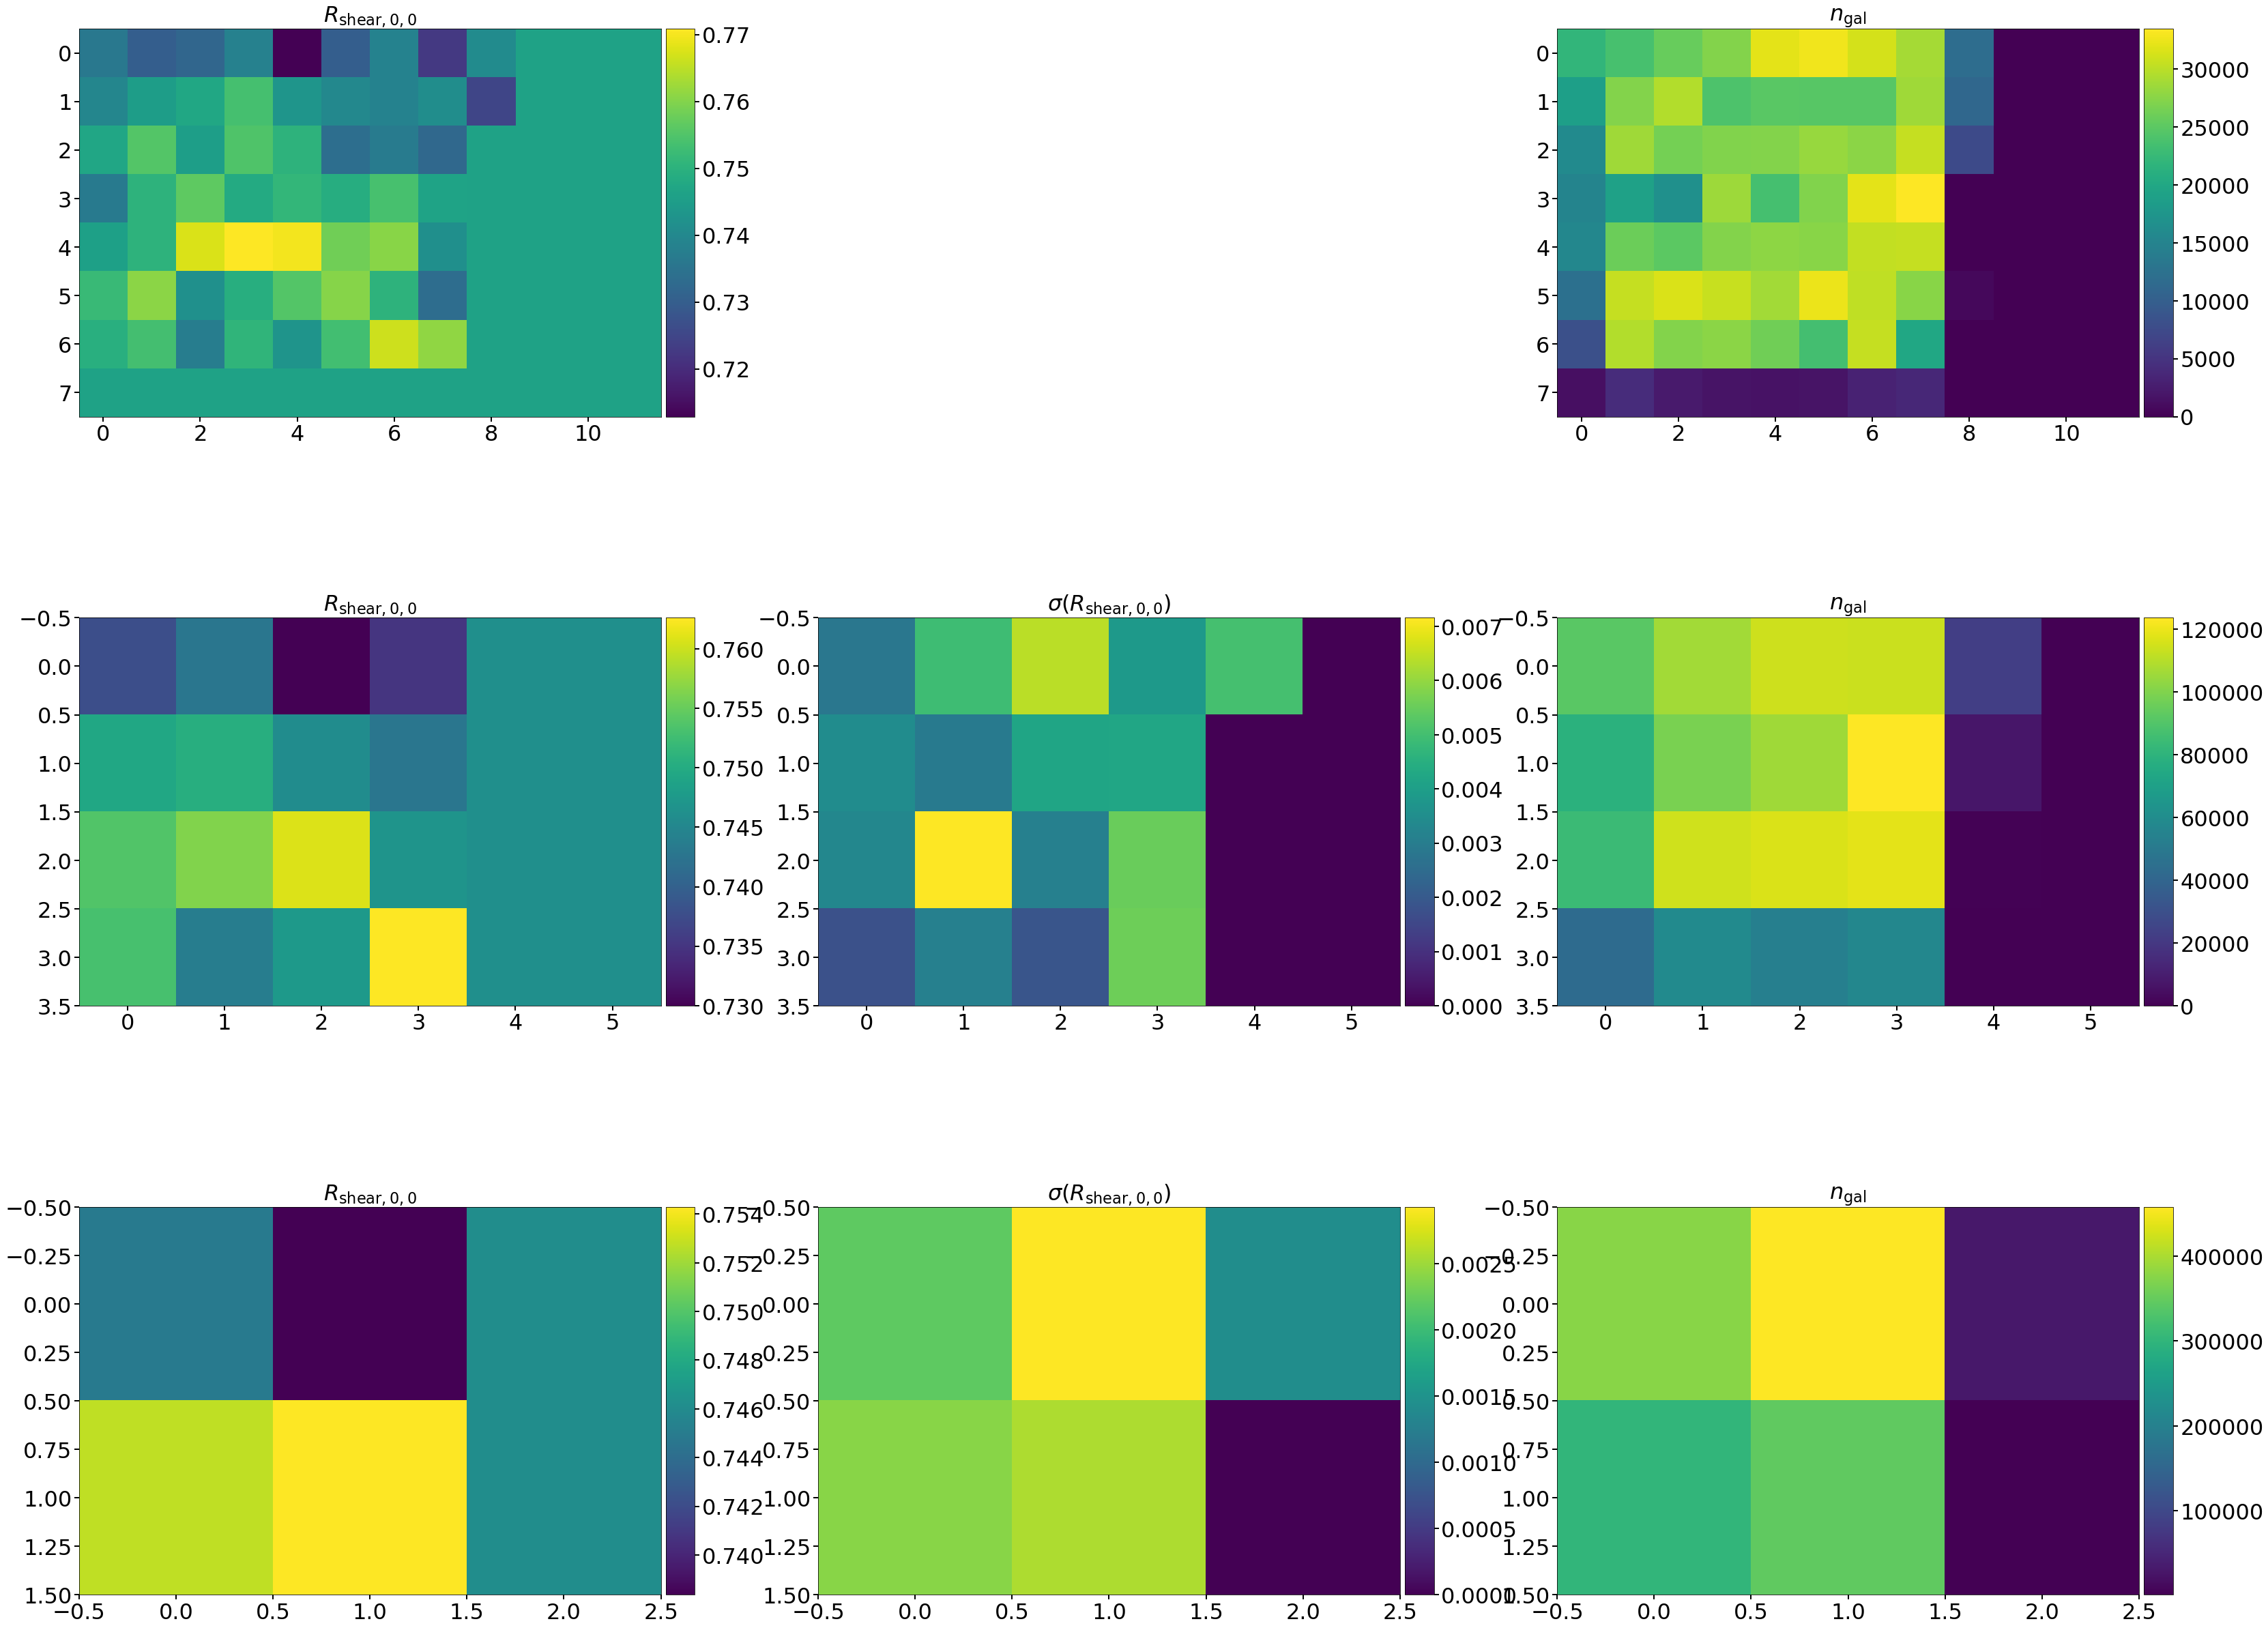

In [84]:
# Plot shear matrix
plt.figure(figsize=(55, 45))

c1 = 0
c2 = 0

for i, cal_pix in enumerate(cal_pix_size_deg):

    subf = 3*i + 1
    sub_plot(n_cal, 3, subf, R_shear_local[cal_pix][c1, c2], rf'$R_{{\rm shear, {c1}, {c2}}}$')
    if cal_pix in R_selec_std_local:
        sub_plot(n_cal, 3, subf+1, R_shear_std_local[cal_pix][0, 0], rf'$\sigma(R_{{\rm shear, {c1}, {c2}}})$')
    sub_plot(n_cal, 3, subf+2, ngal[cal_pix], r'$n_{{\rm gal}}$')
        
plt.savefig(f'{plot_dir_local}/R_shear.pdf')

<ipython-input-78-f5eb70913ecb>:18: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.subplot(nx, ny, i)


<Figure size 3960x3240 with 0 Axes>

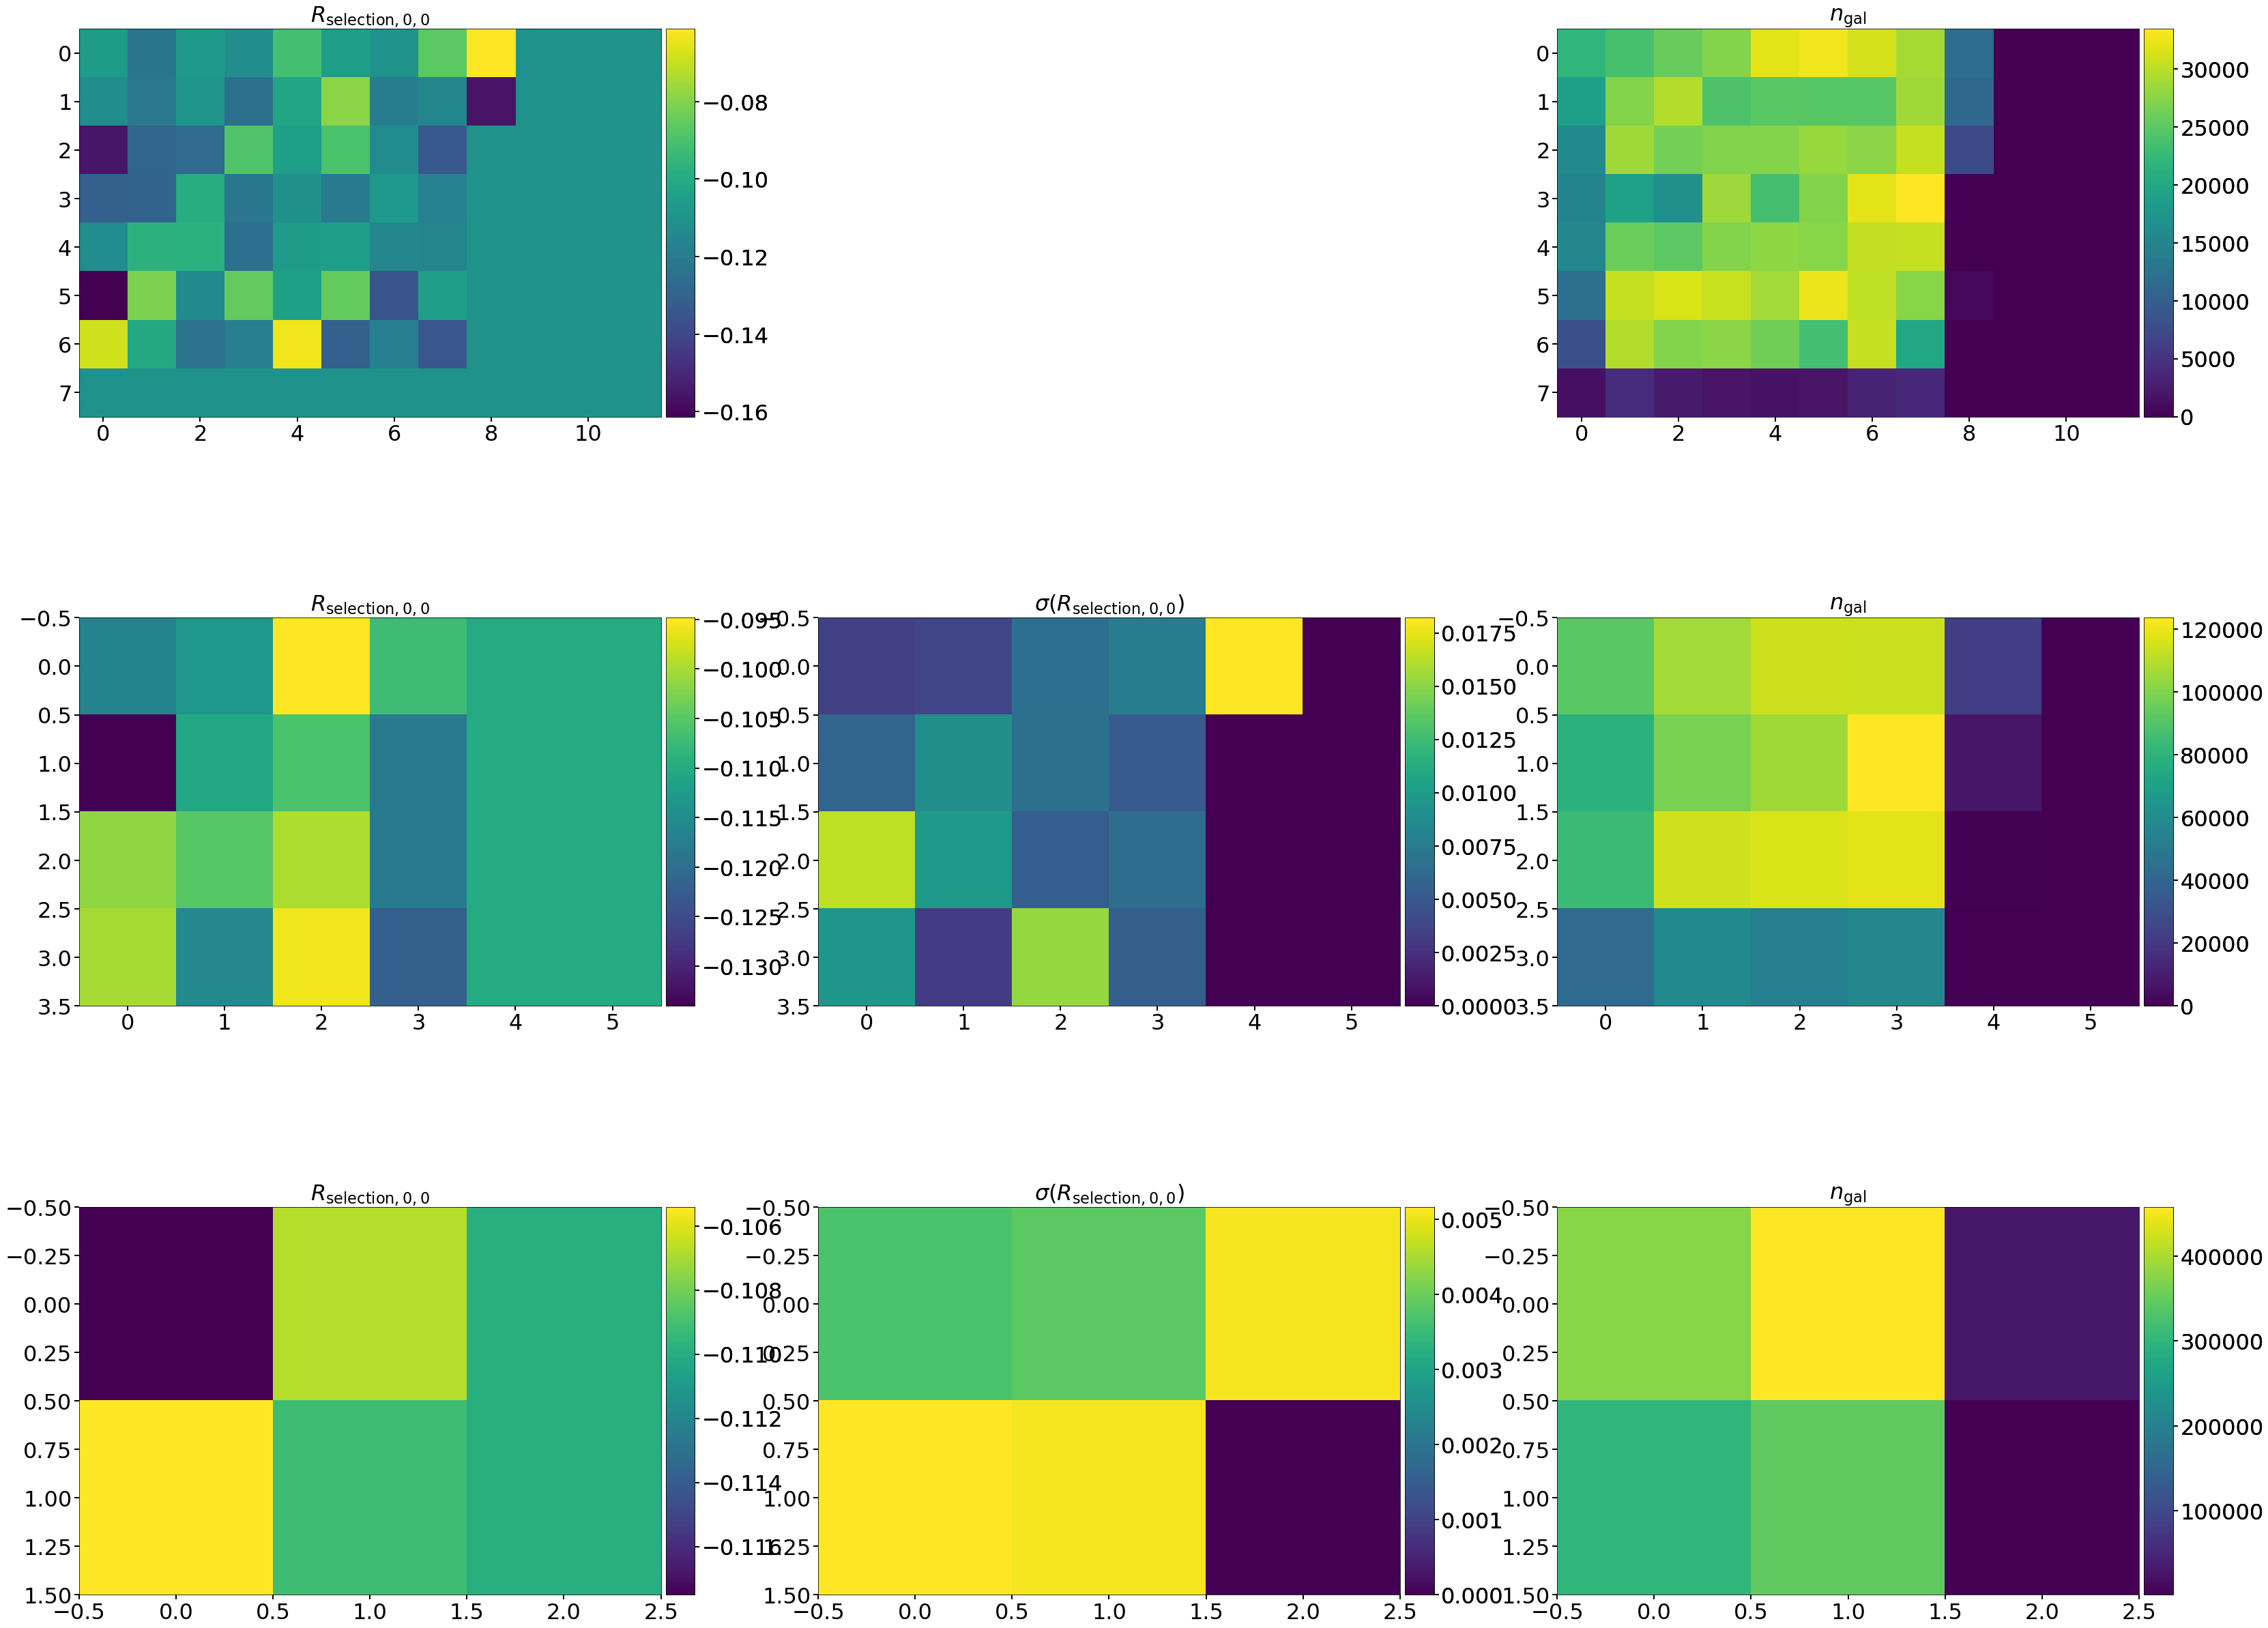

In [85]:
# Plot selection matrix
plt.figure(figsize=(55, 45))

c1 = 0
c2 = 0# Plot selection matrix
plt.figure(figsize=(55, 45))

c1 = 0
c2 = 0

for i, cal_pix in enumerate(cal_pix_size_deg):

    subf = 3*i + 1
    sub_plot(n_cal, 3, subf, R_selec_local[cal_pix][c1, c2], rf'$R_{{\rm selection, {c1}, {c2}}}$')
    if cal_pix in R_selec_std_local:
        sub_plot(n_cal, 3, subf+1, R_selec_std_local[cal_pix][0, 0], rf'$\sigma(R_{{\rm selection, {c1}, {c2}}})$')
    sub_plot(n_cal, 3, subf+2, ngal[cal_pix], r'$n_{{\rm gal}}$')
        
plt.savefig(f'{plot_dir_local}/R_selec.pdf')

for i, cal_pix in enumerate(cal_pix_size_deg):

    subf = 3*i + 1
    sub_plot(n_cal, 3, subf, R_selec_local[cal_pix][c1, c2], rf'$R_{{\rm selection, {c1}, {c2}}}$')
    if cal_pix in R_selec_std_local:
        sub_plot(n_cal, 3, subf+1, R_selec_std_local[cal_pix][0, 0], rf'$\sigma(R_{{\rm selection, {c1}, {c2}}})$')
    sub_plot(n_cal, 3, subf+2, ngal[cal_pix], r'$n_{{\rm gal}}$')
        
plt.savefig(f'{plot_dir_local}/R_selec.pdf')

In [86]:
# Histograms

y_label = 'frequency'
n_bin = 50

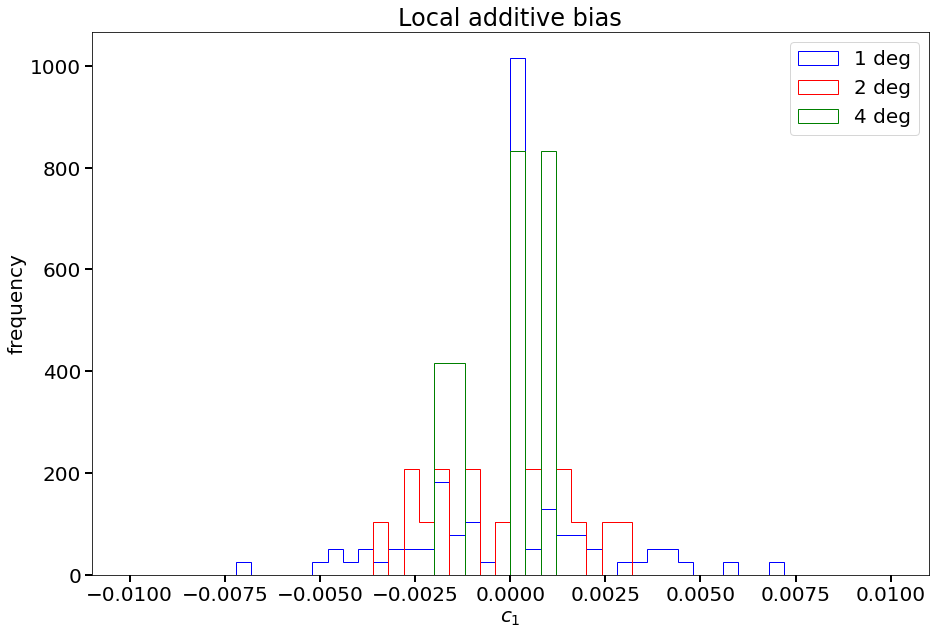

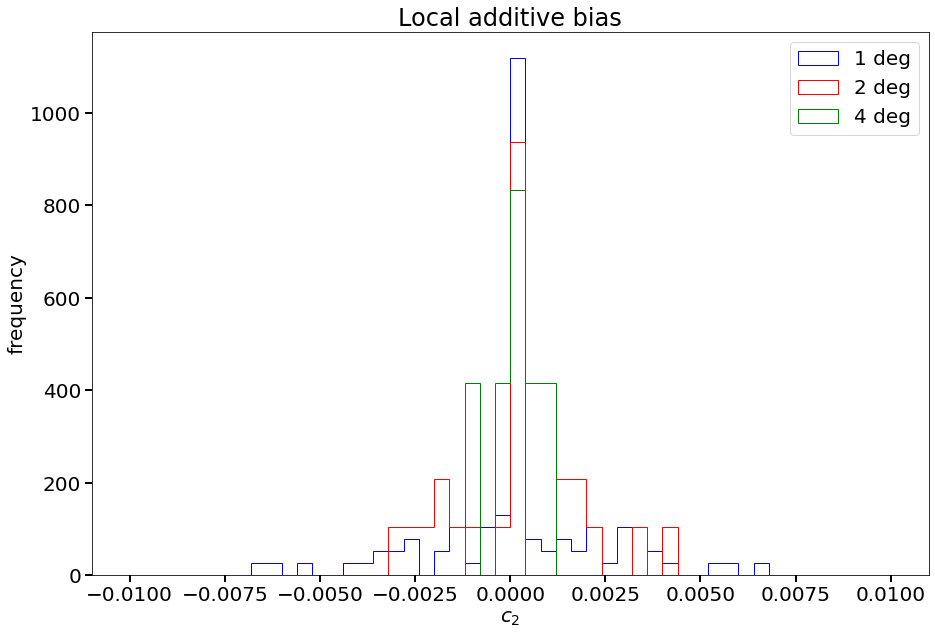

In [87]:
title = 'Local additive bias'
x_range = [-0.01, 0.01]

for comp in (0, 1):

    xs = []
    labels = []
    x_label = rf'$c_{comp+1}$'
    out_path = f'{plot_dir_local}/c_{comp+1}_hist.pdf'

    for cal_pix in cal_pix_size_deg:
        
        xs.append(np.ravel(c_ngmix_local[cal_pix][comp]))
        labels.append(f'{cal_pix} deg')

    plot_histograms(xs, labels, title, x_label, y_label, x_range, n_bin, out_path,
                    colors=colors, linestyles=linestyles)

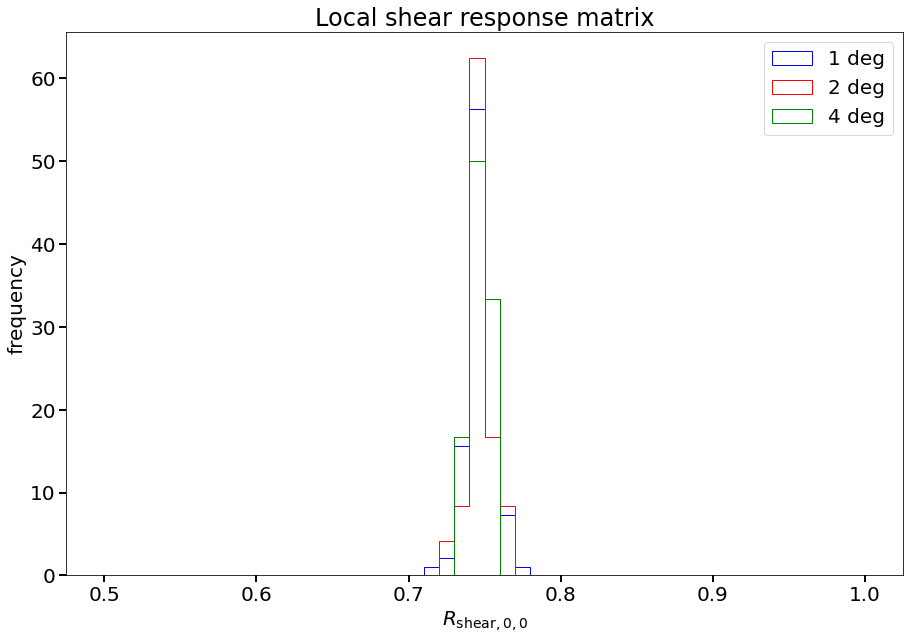

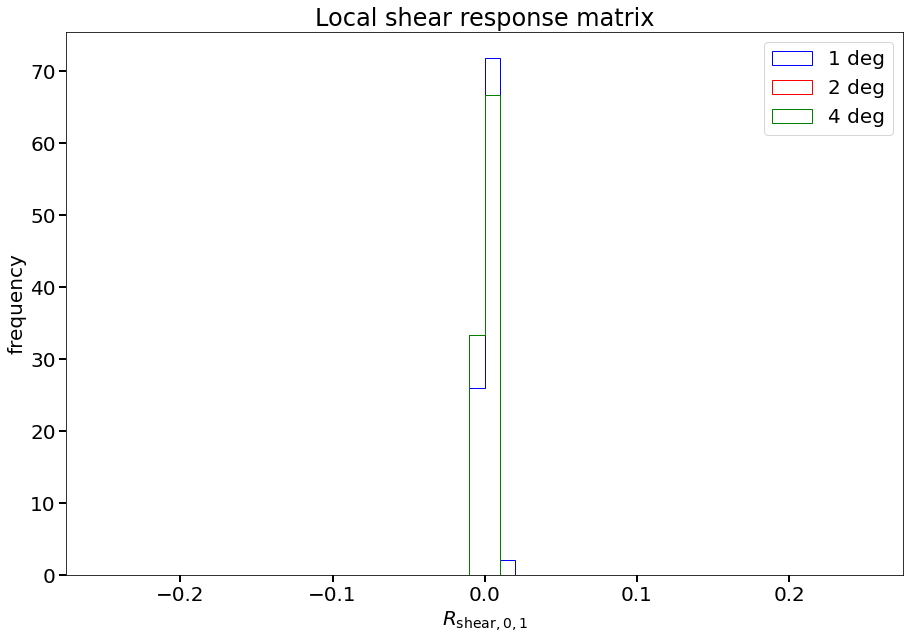

In [88]:
title = 'Local shear response matrix'
x_range = [[0.5, 1], [-0.25, 0.25]]

for i, comp in enumerate(((0, 0), (0, 1))):

    xs = []
    labels = []
    x_label = rf'$R_{{\rm shear, {comp[0]}, {comp[1]}}}$'
    out_path = f'{plot_dir_local}/R_shear_hist.pdf'

    for cal_pix in cal_pix_size_deg:
        
        xs.append(np.ravel(R_shear_local[cal_pix][comp[0], comp[1]]))
        labels.append(f'{cal_pix} deg')

    plot_histograms(xs, labels, title, x_label, y_label, x_range[i], n_bin, out_path,
                    colors=colors, linestyles=linestyles)

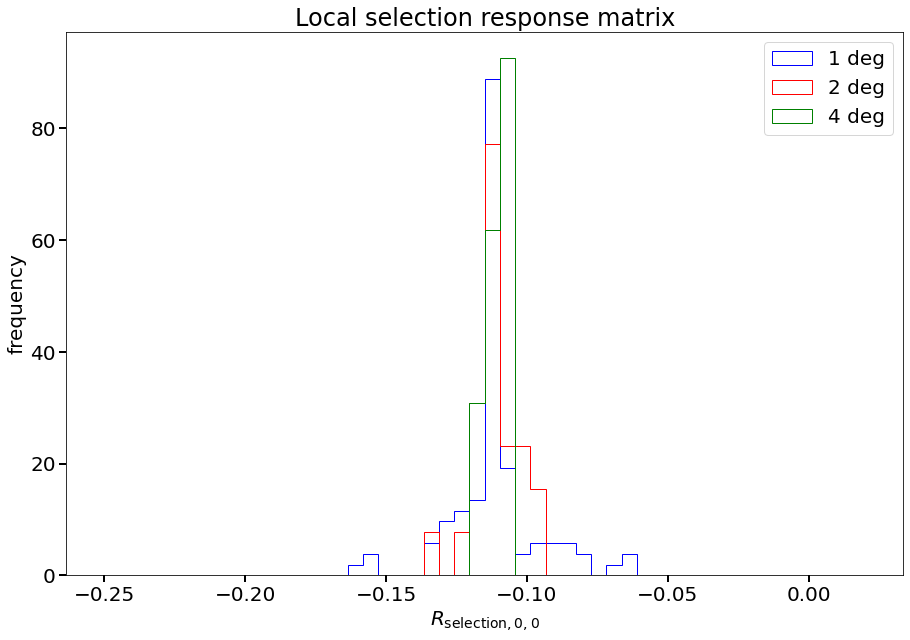

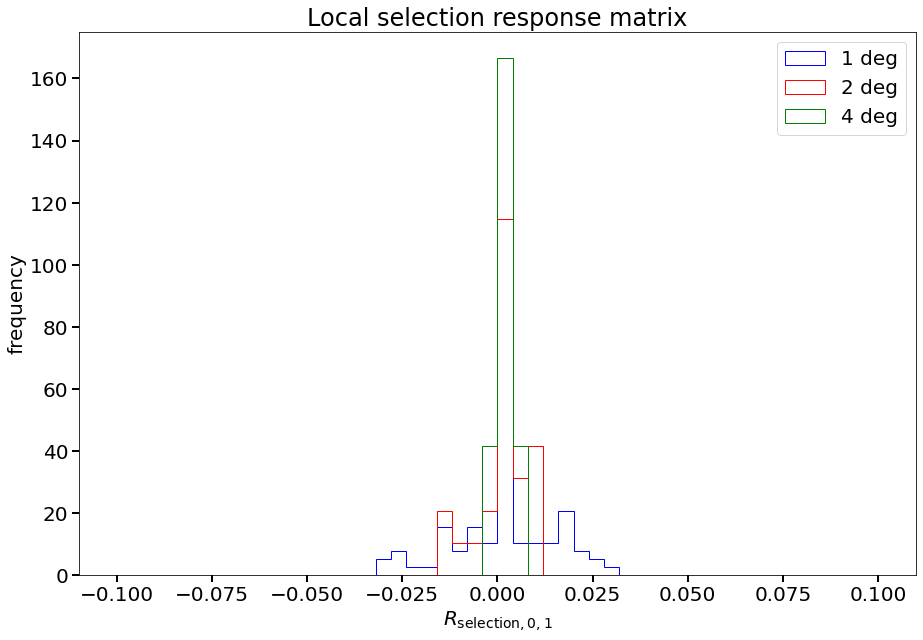

In [89]:
title = 'Local selection response matrix'
x_range = [[-0.25, 0.02], [-0.1, 0.1]]

for i, comp in enumerate(((0, 0), (0, 1))):

    xs = []
    labels = []
    x_label = rf'$R_{{\rm selection, {comp[0]}, {comp[1]}}}$'
    out_path = f'{plot_dir_local}/R_selec_hist.pdf'

    for cal_pix in cal_pix_size_deg:
        
        xs.append(np.ravel(R_selec_local[cal_pix][comp[0], comp[1]]))
        labels.append(f'{cal_pix} deg')

    plot_histograms(xs, labels, title, x_label, y_label, x_range[i], n_bin, out_path,
                    colors=colors, linestyles=linestyles)